# Belt Exam : Time Series Analysis, Tableau


- Mays Nassar

# Load Data and Libraries

In [143]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
#import tick customization tools
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
## Setting figures to timeseries-friendly
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_context("talk", font_scale=0.9)
# set random seed
SEED = 321
np.random.seed(SEED)
#display more columns
pd.set_option('display.max_columns',50)

In [144]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [145]:
# Load data
url = ('/content/drive/MyDrive/AXSOSACADEMY/Time Series Analysis/Week24/zillow_home_values-zipcode.csv')
df = pd.read_csv(url)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,29022000,31032000,30042000,31052000,30062000,31072000,31082000,30092000,31102000,30112000,31122000,31012001,28022001,31032001,30042001,...,30112020,31122020,31012021,28022021,31032021,30042021,31052021,30062021,31072021,31082021,30092021,31102021,30112021,31122021,31012022,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,107274.0,107076.0,107081.0,107112.0,107325.0,107480.0,107709.0,108092.0,108328.0,108782.0,109187.0,109242.0,109045.0,108514.0,108330.0,...,204564.0,206902.0,209154.0,212069.0,213553.0,215782.0,218494.0,223994.0,229959.0,236318.0,241418.0,246015.0,249379.0,253321.0,257274.0,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,222885.0,223602.0,224818.0,224384.0,224051.0,222942.0,223281.0,222886.0,223553.0,224715.0,226127.0,226742.0,226052.0,225191.0,224344.0,...,346146.0,350598.0,354599.0,359133.0,364502.0,370992.0,377896.0,386576.0,397227.0,408018.0,417061.0,424951.0,431973.0,437659.0,443701.0,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,90009.0,90042.0,90007.0,90027.0,89987.0,89972.0,89926.0,89397.0,88767.0,87904.0,87765.0,87719.0,87845.0,87409.0,87119.0,...,144471.0,146280.0,147989.0,149669.0,151475.0,153251.0,155948.0,158804.0,161832.0,164617.0,167493.0,169790.0,171741.0,173354.0,175355.0,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,190588.0,192155.0,194686.0,196246.0,198131.0,200596.0,202906.0,205407.0,208731.0,212367.0,215368.0,217915.0,220488.0,223666.0,226950.0,...,583072.0,582981.0,580157.0,578240.0,577104.0,577493.0,579678.0,579581.0,579996.0,579154.0,580023.0,578203.0,576272.0,572245.0,570414.0,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,277855.0,279802.0,282271.0,283679.0,284880.0,285975.0,288330.0,290339.0,293681.0,296592.0,299017.0,300344.0,302885.0,307212.0,311950.0,...,712619.0,716779.0,721142.0,722880.0,723884.0,724676.0,730056.0,733300.0,735223.0,734912.0,738325.0,741995.0,745001.0,745550.0,748738.0,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


---
<br/>

# **Part 1**

##  Melt the data to long-form and prepare it for time series analysis.

In [146]:
df.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '31012000',
       ...
       '28022022', '31032022', '30042022', '31052022', '30062022', '31072022',
       '31082022', '30092022', '31102022', '30112022'],
      dtype='object', length=284)

In [147]:

id_cols = ['RegionID','SizeRank','RegionName','RegionType','StateName',
           'State','City','Metro','CountyName']
date_cols = [c for c in df.columns if c not in id_cols]

# Melt the data
df_melted = df_large.melt(id_vars=id_cols, value_vars=date_cols,
                   var_name='Date', value_name='Home Value')
df_melted.head(3)

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0


In [148]:
# Convert Date to datetime
df_melted['Date'] = pd.to_datetime(df_melted['Date'],format='%d%m%Y')

# Set Date as index
df_melted = df_melted.set_index('Date')
df_melted.info()
df_melted.head(4)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7546550 entries, 2000-01-31 to 2022-11-30
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  object 
 4   StateName   object 
 5   State       object 
 6   City        object 
 7   Metro       object 
 8   CountyName  object 
 9   Home Value  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 633.3+ MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0


## Prepare a copy for tableau

In [149]:
# Keep data from following states (CA, WA, OR, AZ, NV)
# And keep values from 2010 - 2020
states = ['CA', 'WA', 'OR', 'AZ', 'NV']

tableau_df = df_melted[df_melted['State'].isin(states)].loc['2010':'2020'].copy()


import os
os.makedirs('Data', exist_ok=True)
tableau_df.to_csv('Data/data-for-tableau.csv')

In [150]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/MaysNassar/Belt-Exam.git

fatal: destination path 'Belt-Exam' already exists and is not an empty directory.


In [151]:
!ls /content

Belt-Exam  drive  sample_data


In [152]:
!mv /content/Data /content/Belt-Exam/Data

mv: cannot stat '/content/Data': No such file or directory


In [153]:
!ls /content/Belt-Exam

Belt-Exam  Data  README.md


In [154]:
%cd /content/Belt-Exam
!git add Data/data-for-tableau.csv
!git commit -m "Add tableau data for belt exam"
!git config user.email "maysnasar@gmail.com"
!git config user.name "MaysNassar"
!git push

/content/Belt-Exam
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Belt-Exam/
	Data/Data/

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date


## Resampling to Yearly Frequancy

In [155]:
# Resample to a yearly freq
df_yearly = tableau_df.groupby('State')['Home Value'].resample('YS').mean()

In [156]:
df_yearly.head()

State  Date      
AZ     2010-01-01    169930.889076
       2011-01-01    152272.467002
       2012-01-01    159902.057789
       2013-01-01    183657.225403
       2014-01-01    198551.492521
Name: Home Value, dtype: float64

In [157]:
df_unstacked = df_yearly.unstack(level='State')
df_unstacked.head()

State,AZ,CA,NV,OR,WA
Date,,,,,
2010-01-01,169930.889076,415491.808100,189285.319787,224035.019849,250932.487018
2011-01-01,152272.467002,388468.031550,168931.537037,205273.042225,230557.026098
2012-01-01,159902.057789,388593.634299,165003.293888,201899.022119,225432.142832
2013-01-01,183657.225403,454509.845597,199847.532946,216964.502931,240848.444598
2014-01-01,198551.492521,505808.423831,228975.139535,233022.531108,256869.916239


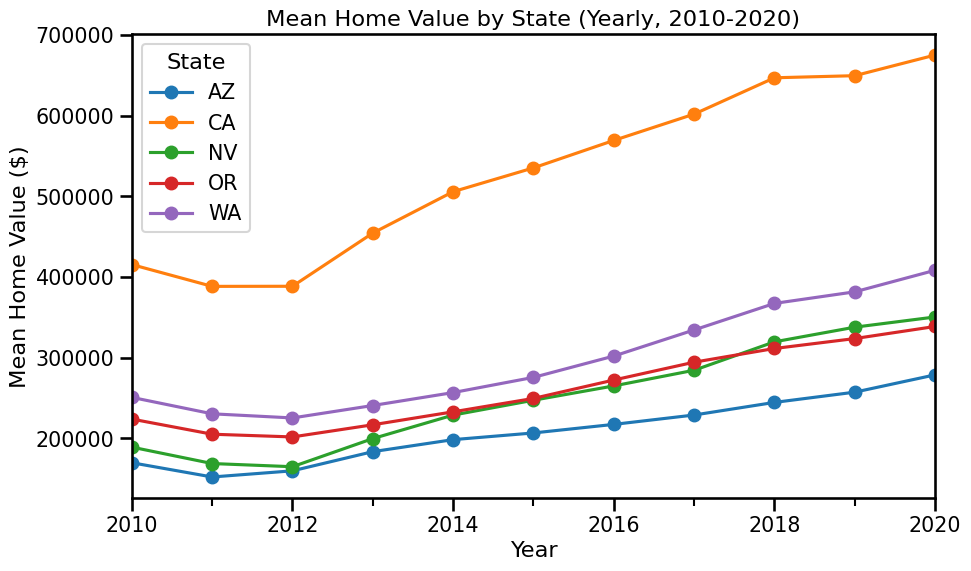

In [158]:
# Plotting 5 states
ax = df_unstacked.plot(figsize=(10,6), marker='o')
ax.set_title('Mean Home Value by State (Yearly, 2010-2020)')
ax.set_ylabel('Mean Home Value ($)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show();

---
<br/>

# **Part 2**

- Goal: Forecast average Oregon home prices for the next 12 months, using historical data from 2000–2018.


<br/>



### Functions

In [159]:
!pip install pmdarima
import pmdarima as pm

In [160]:
import statsmodels.tsa.api as tsa
from pmdarima.arima.utils import ndiffs, nsdiffs

In [161]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                   figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                     forecast_df['mean_ci_lower'],
                     forecast_df['mean_ci_upper'],
                     color='green', alpha=0.3,  lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [162]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
     icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                         "# of Lags Used":nlags,
                         '# of Observations':nobs,
                         'p-value': round(pval,6),
                         'alpha': alpha,
                         'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [163]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error


def regression_metrics(ts_true, ts_pred, label="", verbose =True,
                       output_dict=False):
  # Get the metrics
  mae = mean_absolute_error(ts_true, ts_pred)
  mse = mean_squared_error(ts_true, ts_pred)
  rmse = root_mean_squared_error(ts_true, ts_pred)
  r_squared = r2_score(ts_true, ts_pred)
  mae_perc = mean_absolute_percentage_error(ts_true,ts_pred)*100

  if verbose == True:
    # Print the results with label and header
    header = "-"*60
    print(header, f'Regression Metrics: {label}', header, sep='\n')
    print(f'- MAE = {mae:,.3f}')
    print(f'- MSE = {mse:,.3f}')
    print(f'- RMSE = {rmse:,.3f}')
    print(f'- R^2 = {r_squared:,.3f}')
    print(f'- MAPE = {mae_perc:,.2f}%')

  if output_dict == True:
    metrics = {'Label':label,
               'MAE':mae,
               'MSE':mse,
               'RMSE':rmse,
               'R^2':r_squared,
               'MAPE(%)':mae_perc}

    return metrics

In [164]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):

    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                            })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [165]:
### NEW FUNCTION FOR COMBINED ACF/PACF WITH ANNOTATIONS
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                   annotate_sig=False, alpha=.05,
                   acf_kws={}, pacf_kws={},
                   annotate_seas=False, m = None,
                   seas_color='black'):

  fig, axes = plt.subplots(nrows=2, figsize=figsize)

  # Sig lags line style
  sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
  # ACF
  tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

  ## Annotating sig acf lags
  if annotate_sig == True:
    sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
    for lag in sig_acf_lags:
      axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
  # PACF
  tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

  ## Annotating sig pacf lags
  if annotate_sig == True:
    ## ANNOTATING SIG LAGS
    sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
    for lag in sig_pacf_lags:
      axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

  ### ANNOTATE SEASONS
  if annotate_seas == True:
    # Ensure m was defined
    if m is None:
      raise Exception("Must define value of m if annotate_seas=True.")
    ## Calculate number of complete seasons to annotate
    n_seasons = nlags//m
    # Seasonal Lines style
    seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

    ## for each season, add a line
    for i in range(1, n_seasons+1):
      axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
      axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
  fig.tight_layout()

  return fig

##
------

## Time Series Models for Home Values


In [166]:
df_melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


In [167]:
# Filter only to keep Oregon
# Keep the data from 2000-01-31 to 2018-12-31
ts_or = df_melted[df_melted['State'] == 'OR']['Home Value'].resample('ME').mean()
ts_or =ts_or.loc['2000-01-31':'2018-12-31']
print(ts_or.shape)
ts_or.head()

(228,)


,Home Value
Date,
2000-01-31,162508.613445
2000-02-29,162913.172269
2000-03-31,163011.125523
2000-04-30,163541.908333
2000-05-31,164176.420833


### Check for and address null values

In [168]:
ts_or.isnull().sum()

np.int64(0)

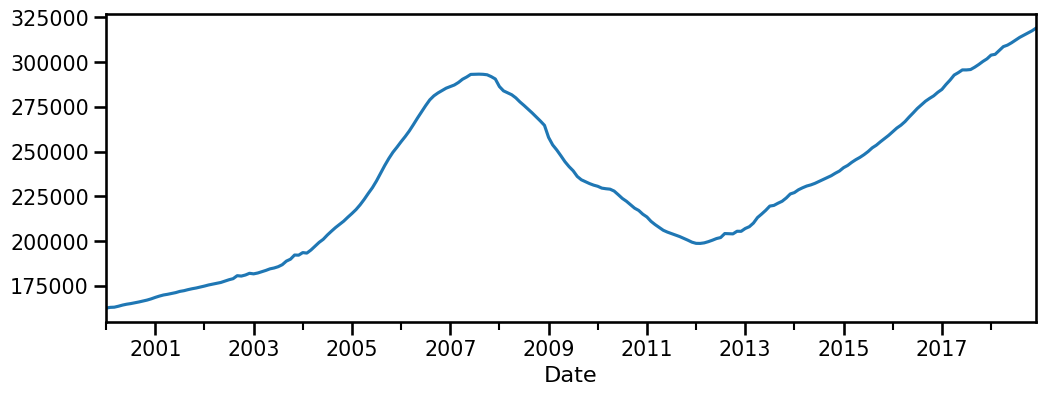

In [169]:
# Plot the data
ts_or.plot();

### Decompose the Time series to detect seasonality


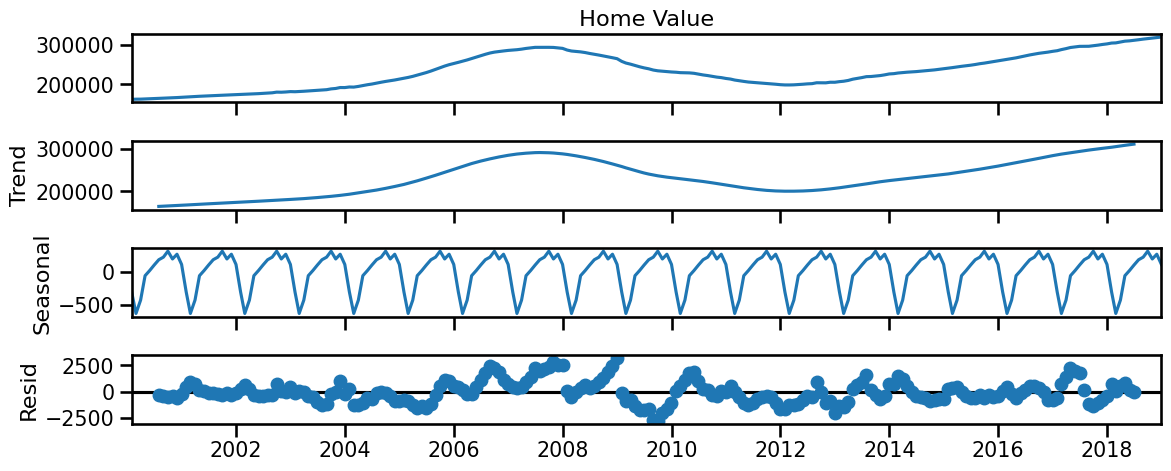

In [170]:
# Apply seasonal decomposition
decomp = tsa.seasonal_decompose(ts_or)
fig = decomp.plot()
fig.set_size_inches(12,5)
fig.tight_layout()

In [171]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

# How big is the seasonal component relative to the time series?
print(f'The Seasonal compnent is {seasonal_delta} which is ~{seasonal_delta/(ts_or.max()-ts_or.min())*100 :.2f}% of the variation in time series.')

The Seasonal compnent is 948.4277802214281 which is ~0.61% of the variation in time series.


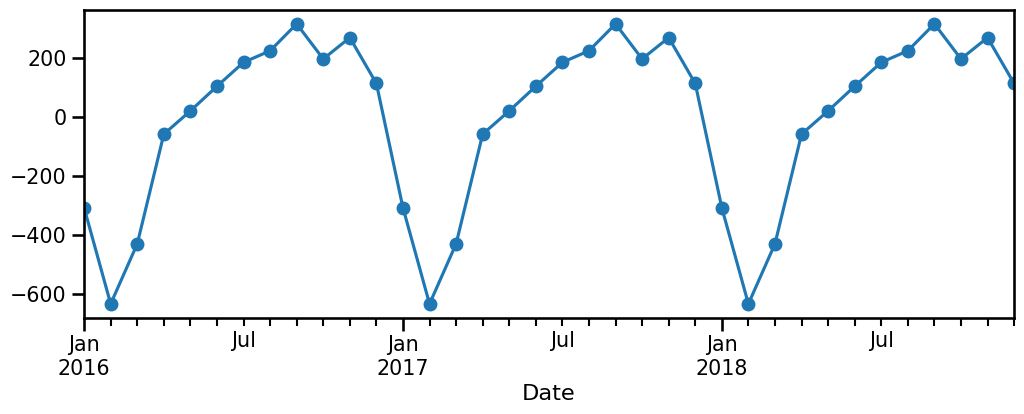

In [172]:
# Narrow down the date range of the plot
seasonal = decomp.seasonal
ax = seasonal.loc['2016': '2018'].plot(marker= 'o');

In [173]:
from scipy.signal import find_peaks
peaks, props = find_peaks(seasonal, height=seasonal.max())

In [174]:
peak_dates = seasonal.index[peaks]

period = peak_dates[1]- peak_dates[0]
periods =[]
for i in range(len(peak_dates)-1):
  delta = peak_dates[i+1]- peak_dates[i]
  periods.append(delta)

In [175]:
import matplotlib.dates as mdates
def plot_seasonal(seasonal):
  minor_loc = mdates.MonthLocator()
  fig, ax = plt.subplots()
  ax.plot(seasonal)
  ax.set(title=f'Seasonal Compnent For Home Value for ORegon {'Monthly'}')
  ax.xaxis.set_minor_locator(minor_loc)
  ax.grid(which='major',axis='x', lw=1,color='k')
  ax.grid(which='minor',axis='x', lw=0.5)
  fig.autofmt_xdate(rotation=90, ha='center')

  return fig, ax

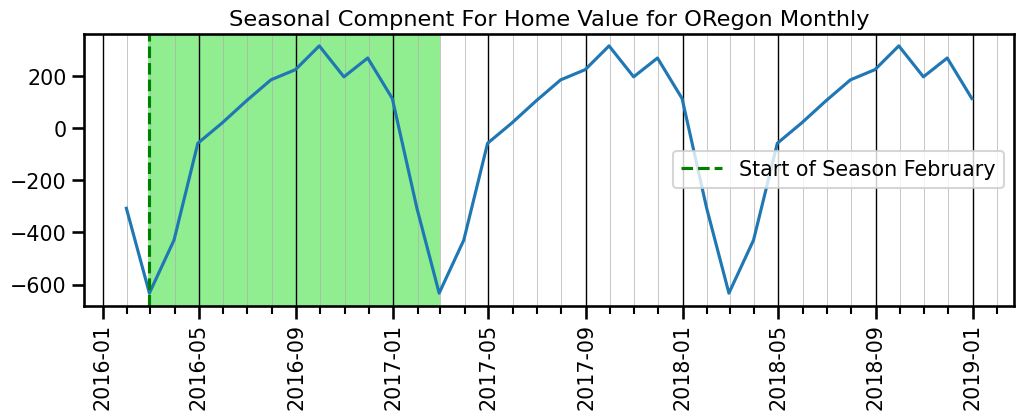

In [176]:
fig , ax = plot_seasonal(seasonal['2016':'2018'])
season_start = seasonal['2016':'2018'].idxmin()
ax.axvspan(season_start, season_start+period, color='lightgreen')
ax.axvline(season_start, color='green', ls='--',
           label=f'Start of Season {season_start.strftime("%B")}')
ax.legend();

In [177]:
avg_period = pd.Series(periods).mean()
print(f"Average cycle length: {avg_period.days} days")

Average cycle length: 365 days


- Yes, there's a recurring seasonal pattern

### Check the time series for stationarity.



In [178]:
# Check for stationarity
get_adfuller_results(ts_or)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


### Determine the number of differencing needed to make the data stationary

In [179]:
# Determine d
d = ndiffs(ts_or)
print(f'd = {d}')
# Determine D
D = nsdiffs(ts_or, m=12)
print(f'D = {D}')

d = 2
D = 0


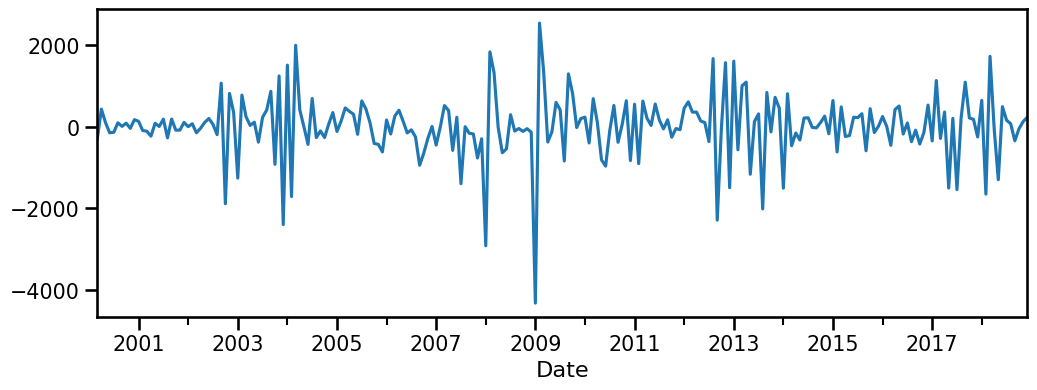

In [180]:
# Apply both differencings
ts_diff = ts_or.diff().diff().dropna()
ts_diff.plot();

In [181]:
ts1_diff = ts_or.diff().dropna()
get_adfuller_results(ts1_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-2.072161,2,224,0.255855,0.05,False


In [182]:
get_adfuller_results(ts_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-13.956007,1,224,0.0,0.05,True


### Check the ACF/PACF Plots of the differenced data to determine the orders

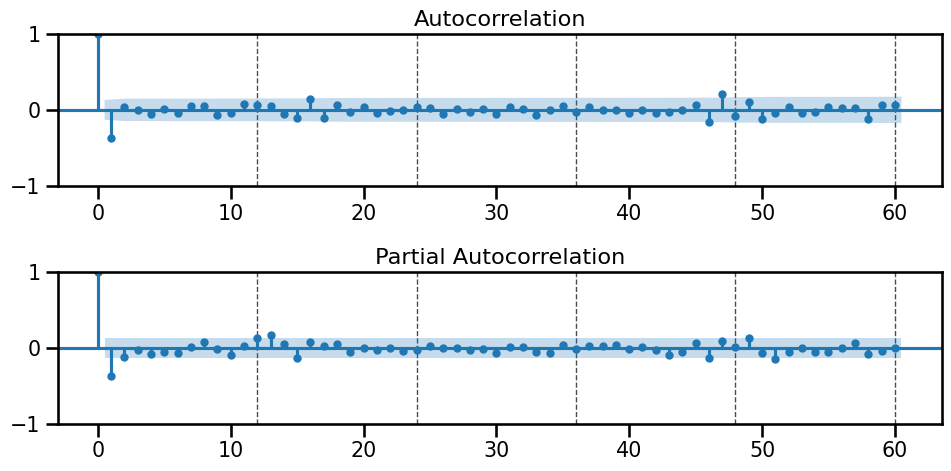

In [183]:
# now look at the acf/pacf of the stationary data
plot_acf_pacf(ts_diff, annotate_seas=True, m=12, nlags=60);

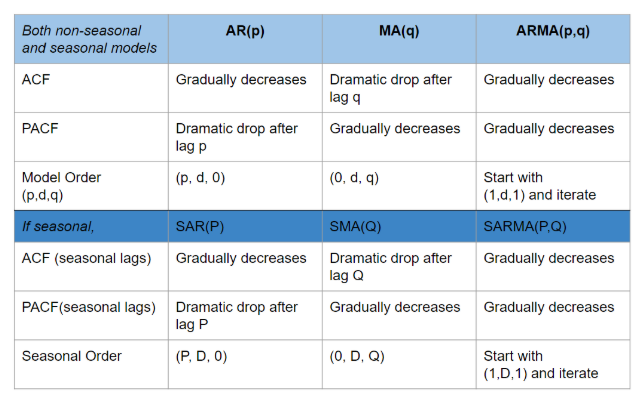

### What Plots of ACF/PACF Says:
Starting with this model (0,2,1)(0,0,0)_12

## Split the time series into training and test data

and we want to predic 12 months

In [184]:
# Find cutoff date for last 12 months
cutoff_date = ts_or.index.max() - pd.DateOffset(months=12)

# Split into train and test
train = ts_or[ts_or.index <= cutoff_date]
test  = ts_or[ts_or.index > cutoff_date]

# Display results
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train size: {len(train)}, Test size: {len(test)}")
print("\nTrain Tail:\n", train.tail())
print("\nTest head:\n", test.head())

Cutoff date: 2017-12-31
Train size: 216, Test size: 12

Train Tail:
 Date
2017-08-31    295847.791045
2017-09-30    297150.110448
2017-10-31    298668.098507
2017-11-30    300367.501493
2017-12-31    301817.988095
Freq: ME, Name: Home Value, dtype: float64

Test head:
 Date
2018-01-31    303915.116766
2018-02-28    304362.766962
2018-03-31    306535.796460
2018-04-30    308659.562130
2018-05-31    309487.658824
Freq: ME, Name: Home Value, dtype: float64


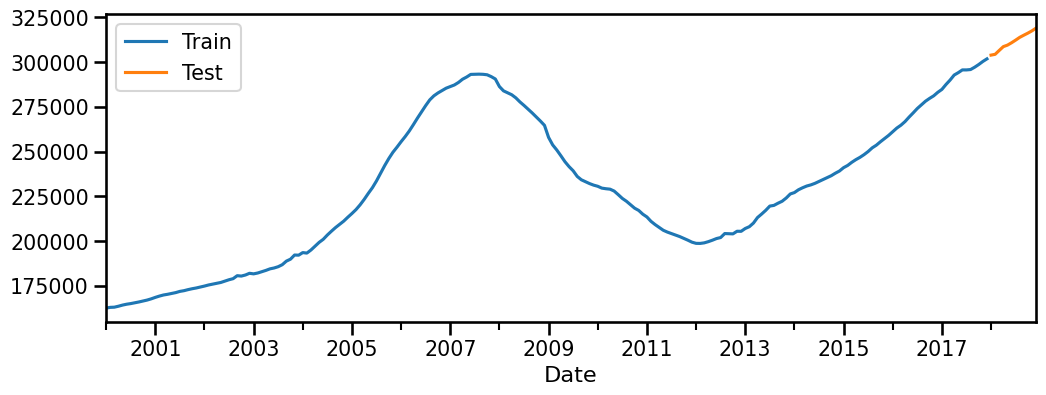

In [185]:
ax = train.plot(label='Train')
test.plot(label='Test', ax=ax)
ax.legend();

## Model 1 Arima (0,2,1)(0,0,0)_12

In [186]:
# Orders for non seasonal components
p = 0  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1 # nonseasonal MA

# Orders for seasonal components
P = 0  # Seasonal AR
D = 0  # Seasonal differencing
Q = 0  # Seasonal MA
m = 12 # Seasonal period

arima_1 = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
arima_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(0, 2, 1)   Log Likelihood               -1726.199
Date:                Fri, 17 Jul 2026   AIC                           3456.399
Time:                        18:22:58   BIC                           3463.131
Sample:                    01-31-2000   HQIC                          3459.119
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0152      0.011     -1.380      0.168      -0.037       0.006
sigma2      5.162e+05   2.21e+04     23.329      0.000    4.73e+05     5.6e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.91   Jarque-Bera (JB):               362.03
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.15
Prob(H) (two-sided):                  0.27   Kurtosis:                         8.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

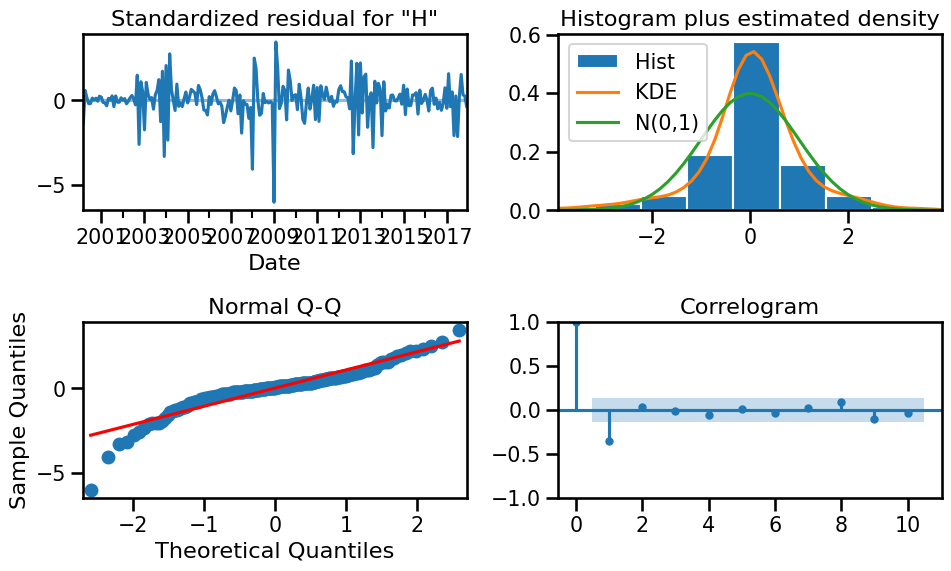

In [187]:
# Obtain diagnostic plots
fig = arima_1.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 381.780
- MSE = 199,058.177
- RMSE = 446.159
- R^2 = 0.991
- MAPE = 0.12%


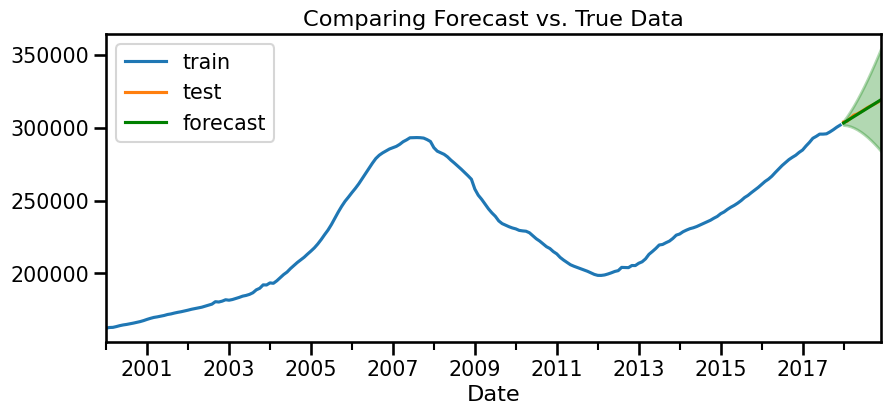

In [188]:
# Obtain summary of forecast as dataframe
forecast_df_1 = arima_1.get_forecast(len(test)).summary_frame()

# Plot the forecast with true values
plot_forecast(train, test, forecast_df_1)

# Obtain metrics
regression_metrics(test, forecast_df_1['mean'])

I picked these orders straight from the ACF/PACF plots on the differenced data. For the differencing order, I needed d=2 — I checked this two ways: the ADF test only showed stationarity (p < 0.05) after differencing twice, and the variance actually dropped from the first to the second difference (2,919,222 → 598,850). That drop matters because if I'd overdone the differencing, variance would have gone up, not down — so d=2 is legit, not overkill. Looking at the ACF and PACF of that twice-differenced series, there was one clear spike at lag 1 and nothing else standing out, which points to q=1 and p=0. I left out seasonal terms entirely — nsdiffs() came back with D=0, the seasonal component from the decomposition was tiny (about $948 against a $145,647 trend range, so under 1%), and there were no spikes at the seasonal lags (12, 24, 36) either. Everything I looked at said this series just doesn't have enough seasonal structure to bother modeling it.

<br/>

----

## Model 2 Arima (0,2,1)(0,0,1)_12



In [189]:
# Orders for non seasonal components
p = 0  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1 # nonseasonal MA

# Orders for seasonal components
P = 0  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

arima_2 = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
arima_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                       Home Value   No. Observations:                  216
Model:             ARIMA(0, 2, 1)x(0, 0, 1, 12)   Log Likelihood               -1726.092
Date:                          Fri, 17 Jul 2026   AIC                           3458.183
Time:                                  18:23:00   BIC                           3468.281
Sample:                              01-31-2000   HQIC                          3462.264
                                   - 12-31-2017                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0152      0.011     -1.385      0.166      -0.037       0.006
ma.S.L12       0.0068      0.035      0.193      0.847      -0.062       0.076
sigma2      5.162e+05   2.71e+04     19.074      0.000    4.63e+05    5.69e+05
===================================================================================
Ljung-Box (L1) (Q):                  27.11   Jarque-Bera (JB):               354.63
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.31   Skew:                            -1.15
Prob(H) (two-sided):                  0.26   Kurtosis:                         8.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

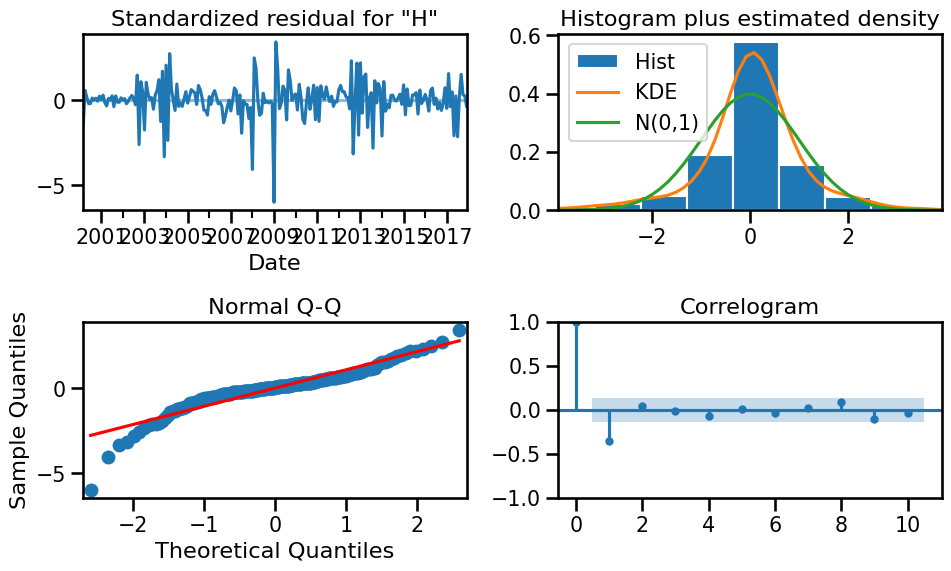

In [190]:
# Obtain diagnostic plots
fig = arima_2.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 376.479
- MSE = 195,350.505
- RMSE = 441.985
- R^2 = 0.992
- MAPE = 0.12%


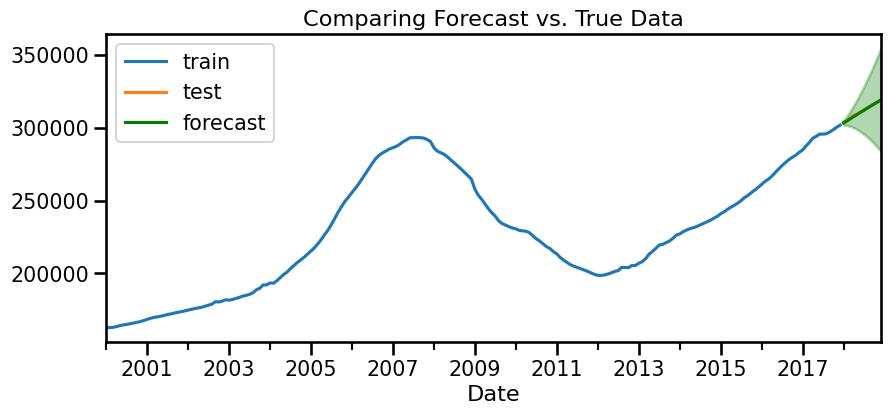

In [191]:
# Obtain summary of forecast as dataframe
forecast_df_2 = arima_2.get_forecast(len(test)).summary_frame()

# Plot the forecast with true values
plot_forecast(train, test, forecast_df_2)

# Obtain metrics
regression_metrics(test, forecast_df_2['mean'])

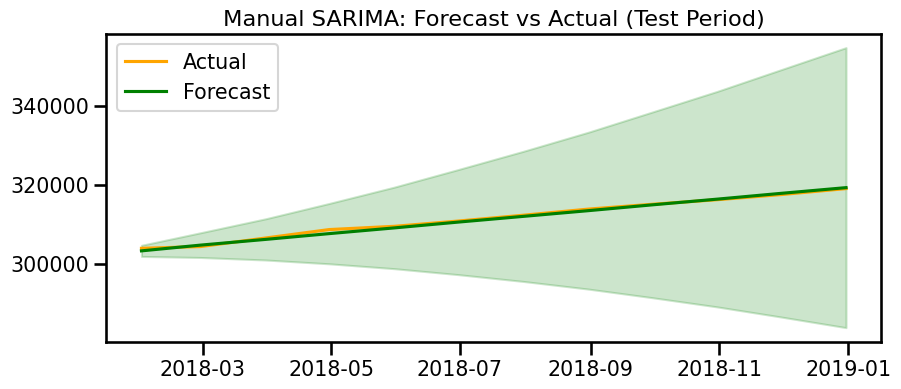

In [192]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test.index, test.values, label='Actual', color='orange')
ax.plot(forecast_df_1.index, forecast_df_1['mean'], label='Forecast', color='green')
ax.fill_between(forecast_df_1.index,
                forecast_df_1['mean_ci_lower'],
                forecast_df_1['mean_ci_upper'],
                alpha=0.2, color='green')
ax.set_title('Manual SARIMA: Forecast vs Actual (Test Period)')
ax.legend();

I wanted to see if adding a seasonal MA term would actually help, even though the seasonal signal looked weak going in. It didn't — AIC got worse, going from 3456.399 (Model 1) to 3458.183 with the seasonal term added. Basically, the small bump in log-likelihood wasn't enough to justify the extra parameter. This backs up what the decomposition already suggested: there just isn't enough seasonality here to make a seasonal model worth it. One thing worth noting — Model 2 actually did a bit better on the 12-month test set (MAE 376.5 vs. 381.8 for Model 1), but with only 12 test points, that's a small enough gap that it's probably just noise. I'm trusting the AIC comparison more here since it's based on all 216 training observations, not just 12.

<br/>

---

---
## Tune with pmdarima's auto_arima

In [193]:
# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(train, seasonal=True,d=2, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=3465.010, Time=0.42 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=3453.299, Time=0.02 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=3458.298, Time=0.07 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=3458.183, Time=0.08 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=3455.380, Time=0.05 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=3455.126, Time=0.15 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=3458.425, Time=0.27 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=3454.641, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=3456.399, Time=0.06 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=3457.674, Time=0.51 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=3455.285, Time=0.03 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 1.768 seconds


In [194]:
# The auto_arima will store our best nonseasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(0, 2, 0)
(0, 0, 0, 12)


In [195]:
# Obtain model summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(0, 2, 0)   Log Likelihood               -1725.649
Date:                Fri, 17 Jul 2026   AIC                           3453.299
Time:                        18:23:03   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.871e+05   2.82e+04     20.794      0.000    5.32e+05    6.42e+05
===================================================================================
Ljung-Box (L1) (Q):                  28.80   Jarque-Bera (JB):               367.75
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.33   Skew:                            -1.14
Prob(H) (two-sided):                  0.23   Kurtosis:                         9.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

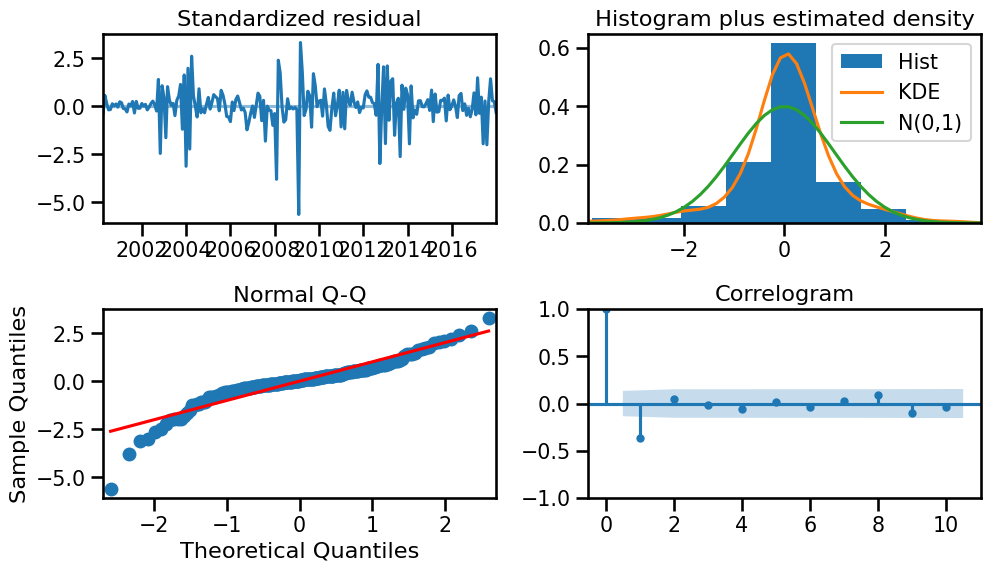

In [196]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 384.272
- MSE = 204,449.052
- RMSE = 452.160
- R^2 = 0.991
- MAPE = 0.12%


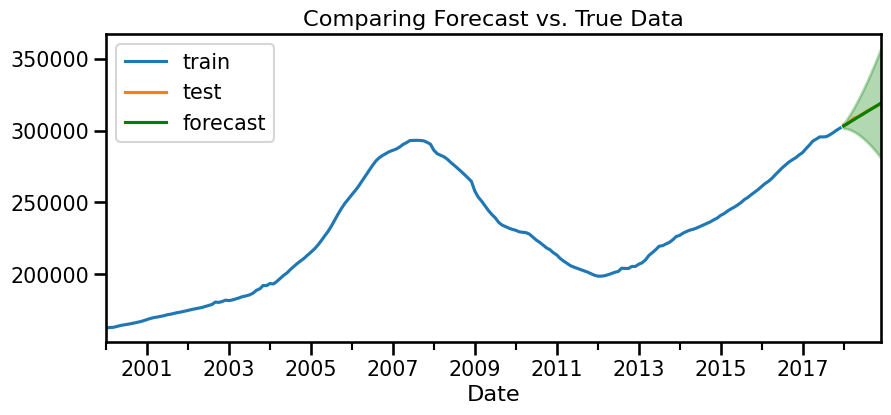

In [197]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(train ,order=auto_model.order,
                       seasonal_order=auto_model.seasonal_order).fit()

# Obtain summary of forecast as dataframe
forecast_df_auto = auto_model.get_forecast(steps=len(test)).summary_frame()

# Plot the forecast with true values
plot_forecast(train, test, forecast_df_auto)

# Obtain metrics
regression_metrics(test, forecast_df_auto['mean'])

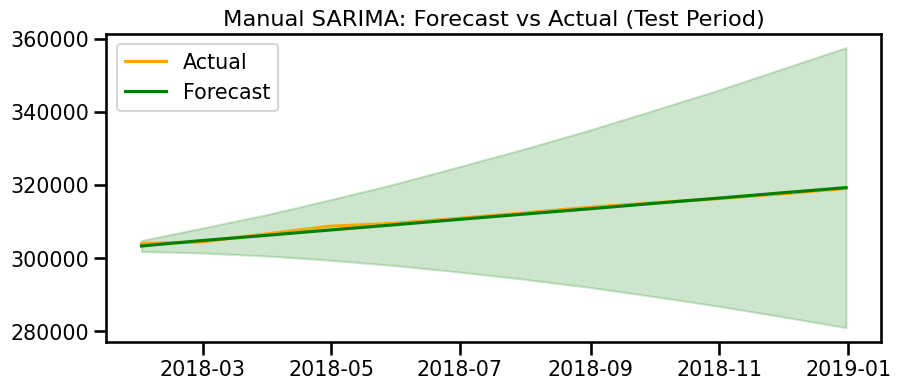

In [198]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test.index, test.values, label='Actual', color='orange')
ax.plot(forecast_df_auto.index, forecast_df_auto['mean'], label='Forecast', color='green')
ax.fill_between(forecast_df_auto.index,
                forecast_df_auto['mean_ci_lower'],
                forecast_df_auto['mean_ci_upper'],
                alpha=0.2, color='green')
ax.set_title('Manual SARIMA: Forecast vs Actual (Test Period)')
ax.legend();

auto_arima's stepwise search independently converged on dropping the MA(1) term entirely, selecting this as the best model by AIC (3453.30 — the lowest of all three candidates). This further supports the "no seasonality" conclusion, since even an unconstrained search that could freely choose seasonal terms (seasonal=True) still landed on (0,0,0)₁₂. However, this model had the worst test-set performance (MAE 384.3, RMSE 452.2) of the three, though the difference from Model 1 is small.

---

<br/>

## Select final model and Make true future forecasts using the entire dataset (for dates beyond the entire ts).

In [212]:
print("-"*60)
print('Manual, no seasonal, ARIMA(0,2,1)(0,0,0)')
print(regression_metrics(test, forecast_df_1['mean']))
print("-"*60)
print('Manual, with seasonal MA, ARIMA(0,2,1)(0,0,1)')
print(regression_metrics(test, forecast_df_2['mean']))
print("-"*60)
print('auto_arima, ARIMA(0,2,0)(0,0,0)')
print(regression_metrics(test, forecast_df_auto['mean']))


------------------------------------------------------------
Manual, no seasonal, ARIMA(0,2,1)(0,0,0)
------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 381.780
- MSE = 199,058.177
- RMSE = 446.159
- R^2 = 0.991
- MAPE = 0.12%
None
------------------------------------------------------------
Manual, with seasonal MA, ARIMA(0,2,1)(0,0,1)
------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 376.479
- MSE = 195,350.505
- RMSE = 441.985
- R^2 = 0.992
- MAPE = 0.12%
None
------------------------------------------------------------
auto_arima, ARIMA(0,2,0)(0,0,0)
------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 384.272
- MSE = 204,449.052
- RMSE = 452.160
- R^2 = 0.991
- MAPE = 0.12%
None


### **Final model selection:**
Selecting Model 1, ARIMA(0,2,1)(0,0,0)₁₂, as the final model. It is directly grounded in the manual ACF/PACF diagnostics rather than an automated search, it has a lower AIC than Model 2 (ruling out the seasonal term), and it outperforms auto_arima's model on the test set while sitting within a negligible AIC gap of it (~3 points). All three candidate models agree that no seasonal component is warranted for this series, which is the more decision-relevant finding here than the small differences in point forecasts between the three.

<br/>

____

<br/>

In [200]:
len(test)

12

In [201]:
# Orders for non seasonal components
p = 0  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1  # nonseasonal MA
# Orders for seasonal components
P = 0  # Seasonal AR
D = 0  # Seasonal differencing
Q = 0  # Seasonal MA
m = 12 # Seasonal period
final_model = tsa.ARIMA(ts_or, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()


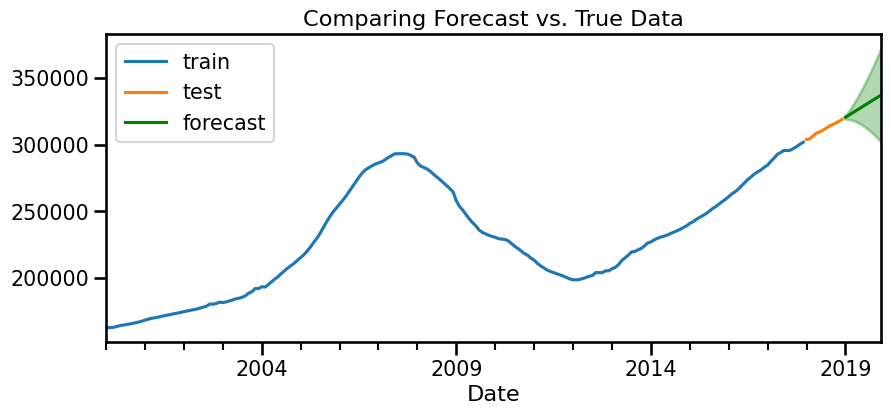

In [202]:
# Obtain futeure forecast beyond test data
future_forecast = final_model.get_forecast(len(test)).summary_frame()


plot_forecast(train,test, future_forecast);

In [203]:
print(future_forecast.index.min(), future_forecast.index.max())

2019-01-31 00:00:00 2019-12-31 00:00:00


In [204]:
future_forecast.head()

Home Value,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-01-31,320539.631544,715.684258,319136.916175,321942.346913
2019-02-28,322054.601324,1589.122893,318939.977687,325169.224961
2019-03-31,323569.571103,2651.071386,318373.566666,328765.575541
2019-04-30,325084.540883,3874.230813,317491.188022,332677.893744
2019-05-31,326599.510663,5240.097606,316329.108080,336869.913245


In [205]:
print(future_forecast['mean'].iloc[-1])

337204.2991198456


In [206]:
# Net change and percent change
net_change = future_forecast['mean'].iloc[-1] - future_forecast['mean'].iloc[0]
pct_change = (net_change / future_forecast['mean'].iloc[0]) * 100
print(f'Net change: {net_change:.0f}')
print(f'Percent change: {pct_change:.2f}%')

Net change: 16665
Percent change: 5.20%


Using our final model — ARIMA(0,2,1) with no seasonal component — fit on the full Oregon home price series from 2000 through 2018, we forecast average home values for the 12 months beyond the data, January through December 2019. The model expects prices to climb from around (320,540) in January to roughly (337,253) by December, a net increase of $16,665, or about 5.20% over the year. That's consistent with the recovery trend already visible in the last several years of the training data — Oregon home values had been climbing steadily since bottoming out around 2012, and the forecast just continues that trajectory forward. We didn't include a seasonal term in the final model; the seasonal signal in the decomposition was small to begin with (under 1% of the trend's overall swing), and every model we tested — including auto_arima's independent search — agreed that a seasonal component didn't earn its keep on AIC.

